In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.nn import functional as F

In [ ]:
!unzip faces.zip -d faces_data

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: faces_data/test/Laura_Bush_0023.jpg  
  inflating: faces_data/test/Laura_Bush_0024.jpg  
  inflating: faces_data/test/Laura_Bush_0025.jpg  
  inflating: faces_data/test/Laura_Bush_0026.jpg  
  inflating: faces_data/test/Laura_Bush_0027.jpg  
  inflating: faces_data/test/Laura_Bush_0028.jpg  
  inflating: faces_data/test/Laura_Bush_0029.jpg  
  inflating: faces_data/test/Laura_Bush_0030.jpg  
  inflating: faces_data/test/Laura_Bush_0031.jpg  
  inflating: faces_data/test/Laura_Bush_0032.jpg  
  inflating: faces_data/test/Laura_Bush_0033.jpg  
  inflating: faces_data/test/Laura_Bush_0034.jpg  
  inflating: faces_data/test/Laura_Bush_0035.jpg  
  inflating: faces_data/test/Laura_Bush_0036.jpg  
  inflating: faces_data/test/Laura_Bush_0037.jpg  
  inflating: faces_data/test/Laura_Bush_0038.jpg  
  inflating: faces_data/test/Laura_Bush_0039.jpg  
  inflating: faces_data/test/Laura_Bush_0040.jpg  
  inflating: f

In [ ]:
transformer = transforms.Compose([
    transforms.ToTensor(),
])
data = datasets.ImageFolder('/content/faces_data', transform=transformer)
data_loader = DataLoader(data, batch_size=50, shuffle=True)

In [ ]:
iterator, _ = next(iter(data_loader))

In [ ]:
iterator.shape

torch.Size([50, 3, 64, 64])

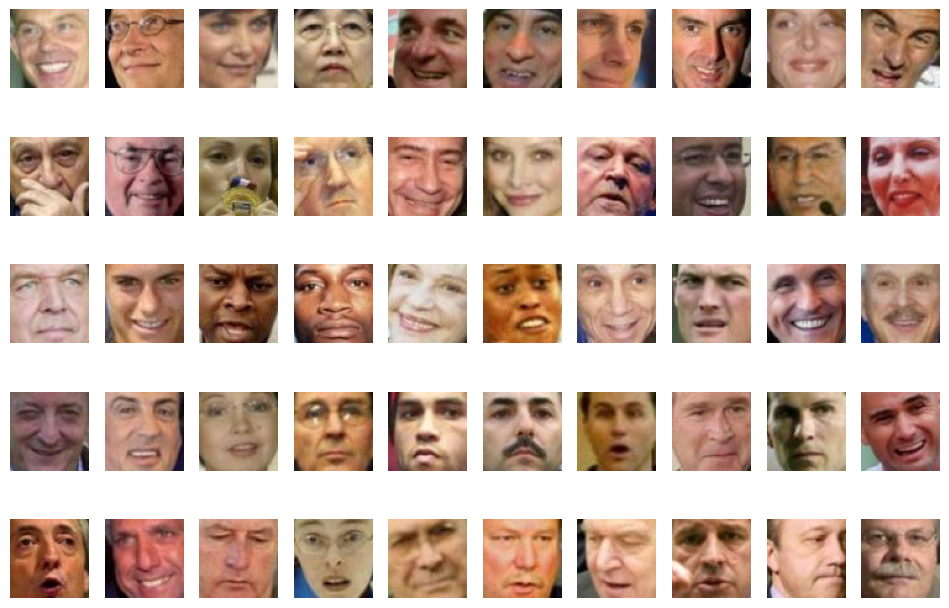

In [ ]:
fig, axs = plt.subplots(5, 10, figsize=(12, 8))
axs = axs.flatten()
for i, ax in enumerate(axs):
  ax.axis('off')
  ax.imshow(iterator[i].permute(1, 2, 0))
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, nc=3, ndf=32, latent_dim=1024):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ndf * 4, ndf * 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(ndf * 8 * 4 * 4, latent_dim * 2)
        )
        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, ndf * 8 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (ndf * 8, 4, 4)),
            nn.ConvTranspose2d(ndf * 8, ndf * 4, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ndf * 4, ndf * 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ndf * 2, ndf, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ndf, nc, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        out = self.encoder(x)
        mu = out[:, :1024]
        logvar = out[:, 1024:]
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def loss_function(recon_x, x, mu, logvar, alpha=0.3):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * MSE + KLD

In [ ]:
vae = VAE()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
vae.train()
for epoch in range(10):
    total_loss = 0.0
    for data in data_loader:
        img, _ = data
        img = img.to(device)
        optimizer.zero_grad()
        reconstructed_img, mu, logvar = vae(img)
        loss = loss_function(reconstructed_img, img, mu, logvar)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f'Эпоха: {epoch+1}, Средняя ошибка: {total_loss / len(data_loader)}')

Эпоха: 1, Средняя ошибка: 4948.9669977152125
Эпоха: 2, Средняя ошибка: 3463.981203935731
Эпоха: 3, Средняя ошибка: 3329.049367998231
Эпоха: 4, Средняя ошибка: 3278.8852668042455
Эпоха: 5, Средняя ошибка: 3243.2186601746757
Эпоха: 6, Средняя ошибка: 3227.970192732901
Эпоха: 7, Средняя ошибка: 3219.8817493366746
Эпоха: 8, Средняя ошибка: 3208.3725595150354
Эпоха: 9, Средняя ошибка: 3188.2972840507077
Эпоха: 10, Средняя ошибка: 3182.403752395342


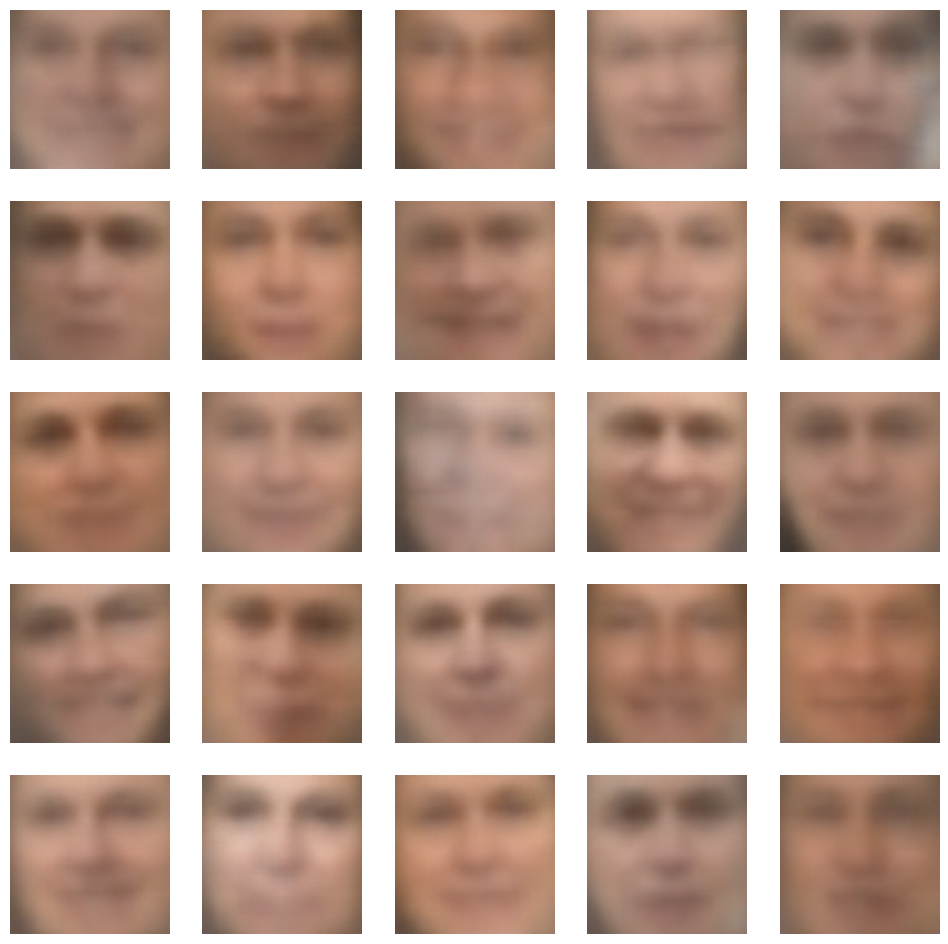

In [ ]:
def generate_sample(vae, latent_dim, num_samples, device):
    vae.eval()
    z = torch.randn(num_samples, latent_dim).to(device)
    with torch.no_grad():
        generated_data = vae.decode(z)
    return generated_data

generated_images = generate_sample(vae,1024, 25, device)

fig, axs = plt.subplots(5, 5, figsize=(12, 12))
axs = axs.flatten()
for i, img in enumerate(generated_images):
    axs[i].imshow(img.permute(1, 2, 0).cpu())
    axs[i].axis('off')
plt.show()